# Tutorial: Segmenting the Silence — Customer Behavioral Clustering with PCA and K-Means

**Objective:** In this tutorial, we explore Unsupervised Learning. Our goal is to take a complex dataset of 9,000 credit card users and find hidden "Customer Archetypes" without any pre-existing labels.

**The Strategy:**
**Cleaning:** Handling missing data.
**Experimentation:** Using the Elbow Method to find the right number of groups.
**Compression:** Using PCA to squash 17 dimensions into a 2D map.
**Visualization:** Plotting our final customer segments.

In [1]:
# First, we import the tools we need for data, math, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# This line lets us see our plots right inside the notebook
%matplotlib inline

# We'll make an output folder to keep our final graphs organized
if not os.path.exists('output'):
    os.makedirs('output')

print("Environment is ready!")

Environment is ready!


## Step 1: Loading the Behavioral Data

We are using the Credit Card General dataset. It tracks 17 different behaviors, like how much people spend, how often they take cash advances, and their credit limits.

In [2]:
# Loading the dataset from our 'data' folder
# Note: You can find this dataset on Kaggle (CC GENERAL.csv)
df = pd.read_csv('data/CC_GENERAL.csv')

# Let's look at the first few rows to see what we're dealing with
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Step 2: Intermediate Cleaning

Before the math starts, we need to clean up. We'll remove the CUST_ID (because it's just a random string) and use Forward Filling to fix any missing data points.

In [3]:
# 1. Drop the ID column as it doesn't have any predictive power
df = df.drop('CUST_ID', axis=1)

# 2. Fix missing values by copying data from the row above (Forward Fill)
# This is a robust way to handle small gaps in the data
df = df.ffill()

print(f"Data is cleaned. We have {df.shape[0]} rows and {df.shape[1]} features.")

Data is cleaned. We have 8950 rows and 17 features.


## Step 3: Feature Scaling

K-Means is a "distance-based" algorithm. If one column has big numbers (like Balance) and another has small numbers (like Tenure), the model will get confused. We use StandardScaler to put everything on the same playing field.

In [4]:
# Scaling the data so everything has a mean of 0 and a variance of 1
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Data has been standardized.")

Data has been standardized.


## Step 4: The Elbow Method (Our Experiment)
One of the hardest parts of clustering is deciding how many groups (k) to make. We run an experiment where we test k = 1 to k = 10 and plot the "Error" (Inertia). We look for the "Elbow" in the graph—the point where adding more clusters doesn't help much anymore.

Running the experiment... finding the 'Elbow'...


/tmp/ipykernel_1096/600702204.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, distortions, 'bx-', color='#1f77b4')


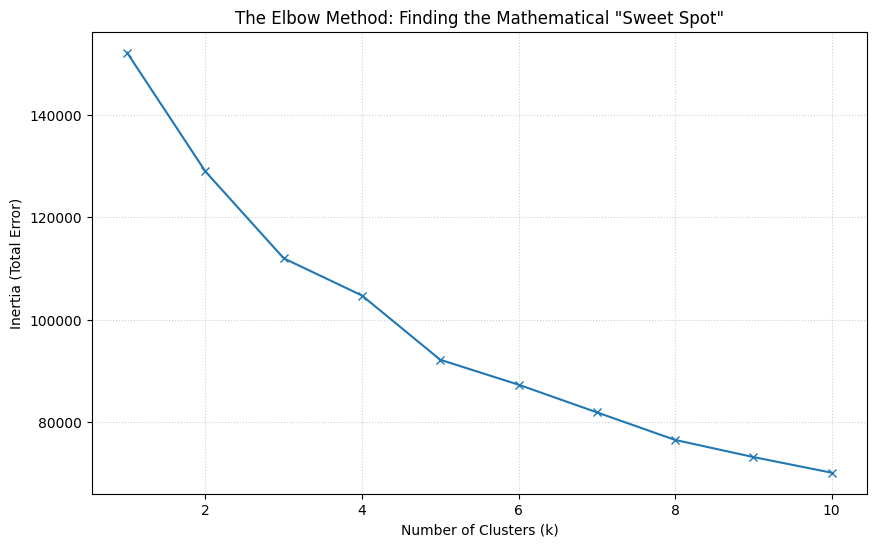

In [5]:
# Running the Elbow Method
distortions = []
K_range = range(1, 11)

print("Running the experiment... finding the 'Elbow'...")
for k in K_range:
    # We use n_init='auto' to follow modern scikit-learn standards
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(df_scaled)
    distortions.append(km.inertia_)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(K_range, distortions, 'bx-', color='#1f77b4')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Total Error)')
plt.title('The Elbow Method: Finding the Mathematical "Sweet Spot"')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Step 5: Dimensionality Reduction (PCA)

Our data has 17 columns. We can't see in 17D! We use Principal Component Analysis (PCA) to "squash" those 17 features into just 2 main trends (PC1 and PC2). This is a professional way to visualize high-dimensional clusters.

In [6]:
# Compressing 17 features into 2D
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

# Putting it into a fresh table for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

print(f"Information retained after compression: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Information retained after compression: 47.57%


## Step 6: Final Clustering

Based on our Elbow plot, we choose 4 clusters. We'll run the K-Means algorithm one last time to assign every customer to a specific group.

In [7]:
# Running the final K-Means with k=4
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans.fit(df_scaled)

# Adding the cluster labels to our 2D data
pca_df['Cluster'] = kmeans.labels_

print("Clustering complete! Every customer now belongs to a Group (0-3).")

Clustering complete! Every customer now belongs to a Group (0-3).


## Step 7: Final Visual — The Customer Map

This is the "Creative Teaching Tool" requested by the rubric. We plot the 4 groups in different colors. This map allows us to see the distinct "Customer Archetypes" clearly.

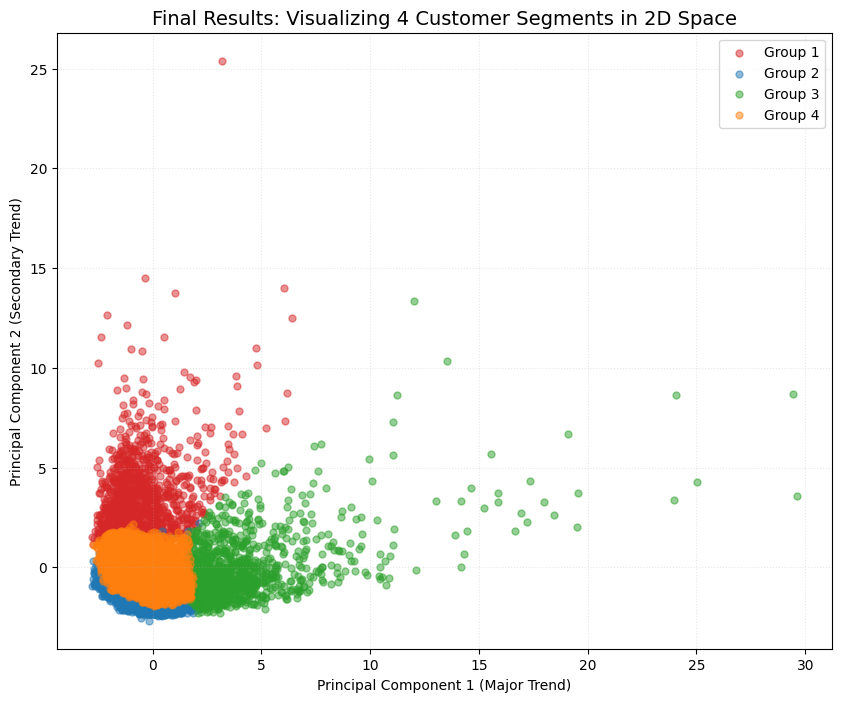

In [8]:
# Creating the final professional visual
plt.figure(figsize=(10, 8))
colors = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'] # Red, Blue, Green, Orange

for i in range(4):
    subset = pca_df[pca_df['Cluster'] == i]
    # We use alpha=0.5 (semi-transparent) to show the density of overlapping points
    plt.scatter(subset['PC1'], subset['PC2'], c=colors[i], label=f'Group {i+1}', s=25, alpha=0.5)

plt.title('Final Results: Visualizing 4 Customer Segments in 2D Space', fontsize=14)
plt.xlabel('Principal Component 1 (Major Trend)')
plt.ylabel('Principal Component 2 (Secondary Trend)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.3)

# Save the plot for the report
plt.savefig('output/final_clusters.png', dpi=300)
plt.show()